# Academic Summary: Image as a Foreign Language: BEiT Pretraining for All Vision and Vision-Language Tasks (BEiT-3)

## Abstract
The paper introduces BEiT-3, a general-purpose multimodal foundation model that unifies vision and vision-language pretraining under a single masked-modeling objective. By treating images as a form of language ("Imglish"), the authors process images, text, and image-text pairs through one shared Multiway Transformer backbone. BEiT-3 achieves state-of-the-art transfer performance across object detection, semantic segmentation, image classification, visual reasoning, visual question answering, image captioning, and cross-modal retrieval, using only publicly available pretraining data.

## Problems
- Existing vision-language foundation models rely on task-specific architectures (dual-encoder, encoder-decoder, fusion-encoder), requiring manual conversion of end-task formats and preventing effective parameter sharing across modalities.
- Prior models typically combine multiple pretraining objectives (image-text contrast, image-text matching, word-region alignment), which complicates scaling and increases engineering overhead.
- Contrastive-based approaches require very large batch sizes (tens of thousands of samples), raising GPU memory and infrastructure costs.
- Many strong foundation models depend on private, non-reproducible in-house datasets, limiting academic reproducibility.

## Proposed Solutions
1. **Multiway Transformers** as a shared backbone: each block contains a shared self-attention module paired with a pool of modality-specific feed-forward experts (vision expert, language expert, and vision-language expert in the top layers), enabling both modality-specific encoding and deep multimodal fusion within one architecture.
2. **Unified masked data modeling** as the sole pretraining task: masked "language" modeling is applied uniformly to monomodal images, monomodal text, and image-text pairs treated as "parallel sentences," eliminating the need for auxiliary contrastive or matching losses.
3. **Model and data scaling**: scaling the backbone to a giant-size (1.9B parameter) configuration following ViT-giant conventions, using exclusively public datasets for both pretraining and finetuning.

## Purpose
The work aims to advance the "big convergence" of language, vision, and multimodal pretraining along three dimensions—backbone architecture, pretraining task, and model scale—so that a single foundation model can be repurposed, with minimal modification, as a vision encoder, language encoder, fusion encoder, dual encoder, or sequence-to-sequence generator across a broad range of downstream tasks.

## Methodology

### Architecture
The Multiway Transformer backbone consists of 40 layers, hidden size 1408, FFN intermediate size 6144, and 16 attention heads, totaling 1.9B parameters (692M vision-expert, 692M language-expert, 52M vision-language-expert, 317M shared attention). Depending on task type, the same backbone is reconfigured as:
- **(a)/(b) Vision/Language Encoders** — for masked image modeling, image classification, segmentation, detection, and masked language modeling.
- **(c) Fusion Encoder** — for deep image-text interaction (VQA, NLVR2).
- **(d) Dual Encoder** — for efficient image-text retrieval via cosine similarity.
- **(e) Image-to-Text Generator** — for autoregressive captioning using a specialized self-attention mask.

### Pretraining Task
Text is tokenized via SentencePiece (64k vocabulary); images are tokenized into discrete visual tokens using the BEiT v2 tokenizer. Masking ratios: 15% for monomodal text, 50% for text in image-text pairs, and 40% of image patches (block-wise masking). Training uses a single mask-then-predict objective across all three data streams, with a batch size of 6144 (2048 images, 2048 texts, 2048 pairs)—substantially smaller than contrastive approaches (CoCa: 65k, CLIP: 32k, Florence: 24k).

### Pretraining Data
| Data Type | Sources | Size |
|---|---|---|
| Image-Text Pairs | CC12M, CC3M, SBU, COCO, VG | 21M pairs |
| Images | ImageNet-21K | 14M images |
| Text | English Wikipedia, BookCorpus, OpenWebText, CC-News, Stories | 160GB |

Optimization uses AdamW ($$\beta_1=0.9, \beta_2=0.98, \epsilon=1e{-}6$$), cosine learning rate decay with peak $$1e{-}3$$, 10k-step linear warmup, weight decay 0.05, stochastic depth (rate 0.1), and BEiT-style initialization for training stability, over 1M steps at $$224 \times 224$$ resolution with $$14 \times 14$$ patches.

### Downstream Task Transfer
- **VQA (VQAv2)**: fusion encoder, formulated as classification over 3129 answer candidates.
- **Visual Reasoning (NLVR2)**: fusion encoder over paired image-text inputs, concatenated pooled outputs classified.
- **Image Captioning (COCO)**: sequence-to-sequence masked finetuning with a captioning-specific attention mask, cross-entropy loss (no CIDEr optimization).
- **Image-Text Retrieval (COCO, Flickr30K)**: dual encoder, with optional intermediate contrastive finetuning on pretraining pairs.
- **Object Detection/Instance Segmentation (COCO)**: ViTDet-style backbone with Cascade Mask R-CNN head, intermediate finetuning on Objects365.
- **Semantic Segmentation (ADE20K)**: ViT-Adapter with Mask2Former framework.
- **Image Classification (ImageNet-1K)**: reformulated as image-to-text retrieval against category-name embeddings, using only public image-tag data.

## Results

| Task | Dataset | Metric | Previous SOTA | BEiT-3 | Gain |
|---|---|---|---|---|---|
| Semantic Segmentation | ADE20K | mIoU | 61.4 (FD-SwinV2) | 62.8 | +1.4 |
| Object Detection | COCO | AP | 63.3 (DINO) | 63.7 | +0.4 |
| Instance Segmentation | COCO | AP | 54.7 (Mask DINO) | 54.8 | +0.1 |
| Image Classification | ImageNet (public) | Top-1 | 89.0 (FD-CLIP) | 89.6 | +0.6 |
| Visual Reasoning | NLVR2 | Acc. | 87.0 (CoCa) | 92.6 | +5.6 |
| Visual QA | VQAv2 | VQA acc. | 82.3 (CoCa) | 84.0 | +1.7 |
| Image Captioning | COCO | CIDEr | 145.3 (OFA) | 147.6 | +2.3 |
| Finetuned Retrieval | COCO | R@1 | 72.5 (Florence) | 76.0 | +3.5 |
| Finetuned Retrieval | Flickr30K | R@1 | 92.6 (Florence) | 94.2 | +1.6 |
| Zero-shot Retrieval | Flickr30K | R@1 | 86.5 (CoCa) | 88.2 | +1.7 |

Additional findings:
- NLVR2 accuracy surpassed 90% for the first time (92.58 test-P).
- Dual-encoder BEiT-3 outperformed fusion-encoder-based models on retrieval while being computationally more efficient, despite not being pretrained with an image-text contrastive loss; intermediate contrastive finetuning provided further gains (e.g., COCO I2T R@1: 82.7 → 84.8).
- On object detection, BEiT-3 reached top results (63.7 box AP, 54.8 mask AP) with a smaller training image size than several competitors.
- Only vision-related parameters (~1B, comparable to ViT-giant) are activated when BEiT-3 is used purely as a vision encoder.

## Conclusions
BEiT-3 demonstrates that a single Multiway Transformer, trained with one unified masked-data-modeling objective across images, text, and image-text pairs, can serve as a general-purpose backbone for vision and vision-language tasks and outperform specialized and contrastively pretrained foundation models—despite using only public data and a substantially smaller pretraining batch size. The results validate treating images as a foreign language for generative pretraining and support the broader convergence of architecture, pretraining task, and model scale as a productive direction for multimodal foundation models. The authors identify future work on multilingual BEiT-3, incorporation of additional modalities (e.g., audio), and combining BEiT-3 with MetaLM to enable in-context learning for multimodal models.

# Mathematical and Statistical Content in BEiT-3

This paper is primarily architectural and empirical; it contains relatively few explicit equations. The mathematical content mostly concerns model configuration formulas, optimization hyperparameters, masking ratios, and evaluation metrics. Each is explained below.

## 1. Parameter Initialization Scaling

**Concept:** BEiT-style initialization is used to stabilize deep Transformer training.

$$
W_l \leftarrow \frac{1}{\sqrt{2l}} \, W_l
$$

**Explanation:** After randomly initializing all parameters within a small range (e.g., $$[-0.02, 0.02]$$), the output projection matrices of the self-attention and feed-forward sublayers at layer $$l$$ are rescaled by $$\frac{1}{\sqrt{2l}}$$. Deeper layers get progressively smaller initial weights. This prevents activation magnitudes from growing uncontrollably as signals pass through 40 stacked layers, which is critical for training very deep (giant-size) Transformers without divergence.

## 2. Masking Ratios (Pretraining Task)

**Concept:** The core self-supervised objective is "mask-then-predict," applied with different probabilities depending on modality.

- Monomodal text: mask **15%** of tokens
- Text in image-text pairs: mask **50%** of tokens
- Images: mask **40%** of patches (block-wise masking)

**Explanation:** These are simple proportions, not equations, but they are statistically meaningful hyperparameters controlling task difficulty. A masking ratio determines what fraction of the input signal is hidden from the model and must be reconstructed from context, directly affecting the difficulty and informativeness of the self-supervised signal. Higher masking on paired text (50%) forces the model to rely more heavily on the image modality to reconstruct meaning, strengthening cross-modal alignment learning.

## 3. Batch Size as a Statistical Sampling Unit

**Concept:** Pretraining batch is decomposed as:

$$
\text{Batch}_{\text{total}} = \text{Batch}_{\text{image}} + \text{Batch}_{\text{text}} + \text{Batch}_{\text{pair}} = 2048 + 2048 + 2048 = 6144
$$

**Explanation:** Each optimization step draws a fixed number of samples from each of the three data streams (monomodal images, monomodal text, and image-text pairs) and combines them into a single batch. This ensures balanced statistical exposure to all modalities during each gradient update. The paper contrasts this modest batch size (6144) with contrastive learning methods requiring 24k–65k samples per batch, arguing that mask-based objectives are statistically more sample-efficient per step.

## 4. Optimizer: AdamW

**Concept:** Standard adaptive moment estimation with decoupled weight decay is used for training.

$$
\theta_{t} = \theta_{t-1} - \eta \left( \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} + \lambda \theta_{t-1} \right)
$$

where $$\hat{m}_t$$ and $$\hat{v}_t$$ are bias-corrected estimates of the first and second moments of the gradient, $$\eta$$ is the learning rate, $$\lambda$$ is the weight decay coefficient.

**Explanation:** AdamW maintains running averages of gradients ($$m_t$$, first moment) and squared gradients ($$v_t$$, second moment) to adapt the effective step size per parameter, while applying weight decay directly to parameters rather than through the gradient (decoupling regularization from adaptive scaling). Reported hyperparameters: $$\beta_1 = 0.9$$, $$\beta_2 = 0.98$$ (pretraining) or $$0.999$$ (finetuning), $$\epsilon = 1e{-}6$$ or $$1e{-}8$$, weight decay $$= 0.05$$ (typically).

## 5. Cosine Learning Rate Schedule

**Concept:** The learning rate follows a cosine decay curve after a linear warmup phase.

$$
\eta_t = \eta_{\text{peak}} \cdot \frac{1}{2}\left(1 + \cos\left(\frac{\pi t}{T}\right)\right), \quad t > t_{\text{warmup}}
$$

**Explanation:** The learning rate starts at zero, increases linearly to a peak value ($$1e{-}3$$) over 10k warmup steps, then smoothly decays following a cosine curve toward zero across the remaining training steps $$T$$. This schedule avoids the abrupt drops of step-based decay and is common practice for stabilizing large-scale Transformer training.

## 6. Layer-wise Learning Rate Decay

**Concept:** Different layers receive different effective learning rates during finetuning.

$$
\eta_l = \eta_{\text{base}} \cdot d^{(L-l)}
$$

where $$d$$ is the decay factor (e.g., 0.8–0.95 depending on task) and $$L - l$$ is the depth from the top layer.

**Explanation:** Layers closer to the output receive the full learning rate, while layers closer to the input receive progressively smaller learning rates (scaled by a decay factor raised to their depth). This reflects the assumption that lower layers encode more general, transferable features that should change less during finetuning, while higher layers need more adaptation to the new task.

## 7. Cosine Similarity (Retrieval and Zero-Shot Classification)

**Concept:** Image and text representations are compared using cosine similarity for dual-encoder retrieval and image classification.

$$
\text{sim}(\mathbf{v}, \mathbf{t}) = \frac{\mathbf{v} \cdot \mathbf{t}}{\|\mathbf{v}\| \, \|\mathbf{t}\|}
$$

**Explanation:** Image embeddings ($$\mathbf{v}$$) and text embeddings ($$\mathbf{t}$$) are separately computed by the dual-encoder configuration, then compared via the cosine of the angle between them. This produces a similarity score independent of vector magnitude, used to rank candidate texts for a given image (or vice versa) in retrieval, and to select the most probable class label by comparing an image embedding against embeddings of candidate class-name texts in zero-shot ImageNet classification.

## 8. Evaluation Metrics

| Metric | Task | Definition (informal) |
|---|---|---|
| **mIoU** (mean Intersection-over-Union) | Semantic Segmentation | Average, over classes, of $$\frac{\text{predicted} \cap \text{ground truth}}{\text{predicted} \cup \text{ground truth}}$$ pixel overlap. |
| **AP** (Average Precision) | Object Detection / Instance Segmentation | Area under the precision-recall curve at varying IoU thresholds, averaged across classes and thresholds. |
| **Top-1 Accuracy** | Image Classification | Percentage of test images where the highest-scoring predicted class matches the true label. |
| **VQA Score** | Visual Question Answering | Soft accuracy metric where an answer's credit is based on agreement with multiple human annotators, typically $$\min\left(\frac{\#\text{matching humans}}{3}, 1\right)$$. |
| **BLEU@4** | Captioning | Precision of overlapping 4-grams between generated and reference captions, with a brevity penalty. |
| **METEOR** | Captioning | Harmonic mean of unigram precision and recall, incorporating synonym/stem matching. |
| **CIDEr** | Captioning | Consensus-based metric weighting n-gram matches by TF-IDF, rewarding agreement with multiple human references. |
| **SPICE** | Captioning | Compares semantic scene-graph content (objects, attributes, relations) between generated and reference captions. |
| **R@K** (Recall at K) | Retrieval | Percentage of queries for which the correct match appears within the top $$K$$ retrieved results (commonly $$K = 1, 5, 10$$). |

**Explanation:** These metrics are the statistical yardsticks by which BEiT-3 is compared against prior state-of-the-art models across the ten benchmarks in Table 1. Each captures a different notion of correctness — pixel overlap, bounding-box/detection quality, exact-match classification, consensus-weighted textual similarity, or ranking-based retrieval success — allowing the paper's central claim (broad state-of-the-art transfer performance) to be substantiated quantitatively.

## 9. Model Scale Accounting

**Concept:** Total parameter count is decomposed additively by module type.

$$
P_{\text{total}} = P_{\text{V-FFN}} + P_{\text{L-FFN}} + P_{\text{VL-FFN}} + P_{\text{Attention}} = 692\text{M} + 692\text{M} + 52\text{M} + 317\text{M} = 1.9\text{B}
$$

**Explanation:** This is a simple sum showing how the 1.9B total parameters are distributed across the vision expert, language expert, vision-language expert, and shared attention modules. It supports the paper's point that only the vision-related parameters (~1B, comparable to ViT-giant) are activated when the model operates purely as a vision encoder, since the language and VL experts are inactive in that mode.

## Summary

Overall, the mathematical content in this paper is largely **applied/statistical** rather than theoretical: it consists of masking probabilities controlling the self-supervised signal, standard deep-learning optimization formulas (AdamW, cosine schedules, layer-wise decay), a similarity function (cosine similarity) enabling cross-modal retrieval and classification, and a battery of standard computer vision and NLP evaluation metrics used to benchmark performance. There are no novel theorems, proofs, or derived statistical models; the paper's contribution is architectural and empirical rather than mathematical in nature.

# Problem–Limitation–Solution Analysis: BEiT-3

| # | Key Problem / Research Gap | Limitation of Prior Work | Proposed Solution in BEiT-3 |
|---|---|---|---|
| 1 | Vision-language models rely on architecture types tailored to specific task formats (dual-encoder for retrieval, encoder-decoder for generation, fusion-encoder for understanding). | Requires manually converting end-task formats to fit specific architectures; parameters are not effectively shared across modalities, reducing generality and increasing engineering complexity. | Introduce **Multiway Transformers** as a single backbone with a shared self-attention module and modality-specific feed-forward experts (vision, language, vision-language), allowing the same network to be reconfigured as vision encoder, language encoder, fusion encoder, dual encoder, or generator. |
| 2 | Vision-language foundation models typically multitask several pretraining objectives (e.g., image-text contrast, image-text matching, word-region alignment). | Multiple simultaneous objectives make training harder to scale up and less efficient, increasing implementation and tuning complexity. | Use a **single unified masked data modeling objective** ("mask-then-predict") applied uniformly to monomodal images, monomodal text, and image-text pairs, treating images as a foreign language ("Imglish") and pairs as "parallel sentences." |
| 3 | Contrastive-based vision-language models (e.g., CLIP, ALIGN, CoCa) require very large batch sizes for effective pretraining. | Large batch sizes (24k–65k samples) introduce substantial GPU memory costs and engineering challenges, limiting accessibility and scalability. | Demonstrate that the mask-then-predict task achieves strong performance with a **much smaller batch size (6144)**, reducing computational and infrastructure burden while maintaining competitive results. |
| 4 | Many strong foundation models (e.g., Florence, Flamingo) depend on private, in-house pretraining data. | Reliance on non-public datasets limits reproducibility and independent verification by the broader research community. | Pretrain and finetune BEiT-3 using **exclusively public, academically accessible data sources** (CC12M, CC3M, SBU, COCO, VG, ImageNet-21K, and public text corpora), while still outperforming models trained on private data. |
| 5 | Foundation models are often specialized for either vision tasks or vision-language tasks, but not evaluated as unified general-purpose backbones across both. | Specialized models achieve strong results in narrow domains but do not demonstrate consistent state-of-the-art performance across a broad, heterogeneous set of vision and vision-language benchmarks. | Evaluate a **single pretrained backbone** across ten diverse benchmarks (object detection, instance/semantic segmentation, image classification, VQA, visual reasoning, captioning, and cross-modal retrieval), showing it can be repurposed with minimal task-specific adaptation. |
| 6 | Prior work has not fully explored the benefits of directly reusing large-scale language-model pretraining pipelines for vision. | Vision and language pretraining pipelines have historically diverged, preventing vision models from leveraging engineering and scaling techniques matured in NLP. | By modeling images as a "foreign language," BEiT-3 **directly reuses the masked-language-modeling pipeline** developed for large-scale text pretraining, enabling model-size and data-size scaling consistent with language-model practices (giant-size, 1.9B-parameter backbone). |

In [1]:
# ============================================================================
# BEiT-3 Style Educational Dual-Encoder for Image-Text Retrieval (Flickr30K)
# ============================================================================
# EDUCATIONAL NOTE:
# This notebook demonstrates the CORE IDEA behind BEiT-3's retrieval fine-tuning
# stage (Figure 3d "Dual Encoder" in the paper): two separate encoders (image
# and text) project their inputs into a SHARED embedding space, and are trained
# with a CONTRASTIVE loss so that matching image-text pairs end up close
# together (high cosine similarity) while non-matching pairs are pushed apart.
#
# This is NOT a reproduction of the original BEiT-3 model. The real BEiT-3:
#   - uses a 1.9B-parameter Multiway Transformer (shared self-attention +
#     modality-specific expert FFNs: V-FFN, L-FFN, VL-FFN)
#   - is pretrained with masked data modeling over images, text, AND
#     image-text pairs jointly (unified mask-then-predict objective)
#   - is only fine-tuned as a dual encoder AFTER this large-scale pretraining
#
# Here, we approximate the DUAL ENCODER FINE-TUNING STAGE ONLY, using a
# lightweight ViT and DistilBERT, trained from their standard pretrained
# checkpoints directly on a small Flickr30K subset with contrastive learning.
# ============================================================================

# ----------------------------------------------------------------------------
# 0. Install & Import Dependencies
# ----------------------------------------------------------------------------
!pip install -q timm transformers datasets scikit-learn

import io
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from IPython.display import Image as IPImage, display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.cuda.amp import autocast, GradScaler

import torchvision.transforms as T

import timm
from transformers import AutoTokenizer, AutoModel

from datasets import load_dataset
from sklearn.decomposition import PCA

In [2]:
# ----------------------------------------------------------------------------
# 1. Reproducibility & Device Setup
# ----------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [3]:
# We check for GPU availability. Google Colab typically provides a CUDA GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# ----------------------------------------------------------------------------
# 2. Global White Theme for Matplotlib (Publication Style)
# ----------------------------------------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "dimgray",
    "grid.color": "lightgray",
    "grid.alpha": 0.5,
    "font.size": 10,
})

In [ ]:
# ----------------------------------------------------------------------------
# 3. Load Flickr30K Dataset from HuggingFace
# ----------------------------------------------------------------------------
# NOTE: Newer versions of the `datasets` library no longer support datasets
# that rely on a custom loading script (a .py file), which is how
# "nlphuji/flickr30k" was originally packaged. To work around this, we load
# the AUTO-CONVERTED PARQUET version of the dataset instead, using the
# special "refs/convert/parquet" revision that HuggingFace generates
# automatically for every scripted dataset.
print("Loading Flickr30K dataset from HuggingFace (this may take a moment)...")

try:
    raw_ds = load_dataset("nlphuji/flickr30k", revision="refs/convert/parquet")
except Exception as e:
    print(f"Parquet revision load failed ({e}), retrying with trust_remote_code...")
    # Fallback: some environments still support scripted datasets if you
    # explicitly opt in. This only works on older `datasets` versions.
    raw_ds = load_dataset("nlphuji/flickr30k", trust_remote_code=True)

available_splits = list(raw_ds.keys())
print(f"Available splits detected: {available_splits}")

base_split_name = available_splits[0]
full_data = raw_ds[base_split_name]
print(f"Using split '{base_split_name}' with {len(full_data)} total examples.")

In [7]:
# ----------------------------------------------------------------------------
# 4. Image Transforms (Train vs Validation)
# ----------------------------------------------------------------------------
# ImageNet normalization statistics, since our ViT backbone is pretrained on
# ImageNet and expects inputs in this distribution.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((224, 224)),           # ensure a consistent base size first
    T.RandomResizedCrop(224),       # random crop + resize for augmentation
    T.RandomHorizontalFlip(),       # random flip for augmentation
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.CenterCrop(224),              # deterministic crop, no augmentation
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [ ]:
# ----------------------------------------------------------------------------
# 5. Tokenizer Setup
# ----------------------------------------------------------------------------
TOKENIZER_NAME = "distilbert-base-uncased"
MAX_CAPTION_LEN = 32

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

In [9]:
# ----------------------------------------------------------------------------
# 6. Custom PyTorch Dataset
# ----------------------------------------------------------------------------
class Flickr30KDataset(Dataset):
    """
    Wraps a HuggingFace Flickr30K split into a PyTorch Dataset.

    Each Flickr30K image usually has MULTIPLE captions stored in a list
    (e.g., example["caption"] = [cap1, cap2, cap3, cap4, cap5]).
    For simplicity and to keep a clean 1-to-1 image-text pairing (as used
    for contrastive retrieval training), we take only the FIRST caption
    for each image.
    """
    def __init__(self, hf_split, transform, tokenizer, max_len=32):
        self.data = hf_split
        self.transform = transform
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        example = self.data[idx]

        # --- Read and process image ---
        image = example["image"]
        image = image.convert("RGB")  # ensure 3-channel RGB
        image_tensor = self.transform(image)

        # --- Read caption(s); Flickr30K stores a LIST of captions per image ---
        captions = example["caption"]
        if isinstance(captions, list):
            raw_caption = captions[0]
        else:
            raw_caption = captions

        # --- Tokenize caption ---
        tokenized = self.tokenizer(
            raw_caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        caption_input_ids = tokenized["input_ids"].squeeze(0)
        attention_mask = tokenized["attention_mask"].squeeze(0)

        return {
            "image_tensor": image_tensor,
            "caption_input_ids": caption_input_ids,
            "attention_mask": attention_mask,
            "raw_caption": raw_caption,
        }

In [10]:
# ----------------------------------------------------------------------------
# 7. Build Train / Validation Subsets
# ----------------------------------------------------------------------------
# We create TWO dataset wrappers over the SAME underlying HF data, one with
# training transforms (augmented) and one with validation transforms
# (deterministic), then slice out small subsets using torch.utils.data.Subset.
train_full_dataset = Flickr30KDataset(full_data, train_transform, tokenizer, MAX_CAPTION_LEN)
val_full_dataset = Flickr30KDataset(full_data, val_transform, tokenizer, MAX_CAPTION_LEN)

NUM_TRAIN = min(2000, len(full_data))
NUM_VAL = min(400, len(full_data))

train_indices = list(range(0, NUM_TRAIN))
# Validation uses a DIFFERENT slice of the data to avoid overlap with training
val_start = NUM_TRAIN
val_end = min(NUM_TRAIN + NUM_VAL, len(full_data))
val_indices = list(range(val_start, val_end))

# Fallback: if dataset is too small for a non-overlapping val slice, reuse
# the tail of the training range instead.
if len(val_indices) < 10:
    val_indices = list(range(max(0, NUM_TRAIN - NUM_VAL), NUM_TRAIN))

train_subset = Subset(train_full_dataset, train_indices)
val_subset = Subset(val_full_dataset, val_indices)

# ----------------------------------------------------------------------------
# 8. DataLoaders
# ----------------------------------------------------------------------------
BATCH_SIZE = 32

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False
)


In [11]:
# ----------------------------------------------------------------------------
# 9. Sanity Check
# ----------------------------------------------------------------------------
print("\n--- Sanity Check ---")
print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")

sample_batch = next(iter(train_loader))
print(f"Image batch shape: {sample_batch['image_tensor'].shape}")
print(f"Token batch shape: {sample_batch['caption_input_ids'].shape}")
print(f"Attention mask shape: {sample_batch['attention_mask'].shape}")
print("First 5 captions in this batch:")
for c in sample_batch["raw_caption"][:5]:
    print(f"  - {c}")




--- Sanity Check ---
Training samples: 2000
Validation samples: 400
Image batch shape: torch.Size([32, 3, 224, 224])
Token batch shape: torch.Size([32, 32])
Attention mask shape: torch.Size([32, 32])
First 5 captions in this batch:
  - A man preparing to cook fish for his visitors during a local town event organized by nike company.
  - Three women walking down the sidewalk with smiles on their faces.
  - A young woman with red highlights in her hair is applying eyeshadow with a Q-tip in front of a mirror.
  - Two people are holding a large upside-down earth globe, about 4' in diameter, and a child appears to be jumping over Antarctica.
  - A man wearing a black sweater cooks food in a pan while standing in a cluttered kitchen.


In [ ]:
# ============================================================================
# 10. Model Architecture: Simplified BEiT-3 Style Dual Encoder
# ============================================================================
#
# EDUCATIONAL NOTE — Dual Encoder vs Fusion Encoder:
# BEiT-3 can be configured as either a FUSION encoder (jointly processes
# image + text tokens together with cross-attention, used for VQA/NLVR2) or
# a DUAL encoder (encodes image and text SEPARATELY into independent
# embeddings, used for retrieval). Dual encoders are much faster at retrieval
# time because you can pre-compute all image/text embeddings once, then
# just compare vectors with cosine similarity — no need to re-run a joint
# forward pass for every possible image-text combination.
# ============================================================================

EMBED_DIM = 256  # shared embedding space dimensionality (paper analogy: 768 -> 256)

class ProjectionHead(nn.Module):
    """
    Projects a modality-specific embedding (e.g., 768-dim from ViT or BERT)
    into a smaller SHARED embedding space where images and text can be
    directly compared.

    Why do we need this? The raw outputs of the image encoder and text
    encoder live in DIFFERENT, unrelated vector spaces. The projection head
    learns a mapping into a common space where semantic alignment (contrastive
    learning) can occur.
    """
    def __init__(self, input_dim, output_dim=EMBED_DIM):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.gelu = nn.GELU()
        self.layer_norm = nn.LayerNorm(output_dim)

    def forward(self, x):
        x = self.linear(x)
        x = self.gelu(x)
        x = self.layer_norm(x)
        return x


class ImageEncoder(nn.Module):
    """
    Lightweight Vision Transformer (ViT-Tiny via timm) used as an
    APPROXIMATION of BEiT-3's Vision Expert pathway (V-FFN branch in the
    Multiway Transformer). We remove the classification head since we only
    need a global image representation (embedding), not class logits.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        # ViT-Tiny: a small, fast Vision Transformer pretrained on ImageNet.
        self.backbone = timm.create_model(
            "vit_tiny_patch16_224", pretrained=True, num_classes=0  # num_classes=0 removes the head
        )
        backbone_dim = self.backbone.num_features  # typically 192 for ViT-Tiny
        self.projection = ProjectionHead(backbone_dim, embed_dim)

    def forward(self, images):
        features = self.backbone(images)          # (batch, backbone_dim)
        embeddings = self.projection(features)     # (batch, embed_dim)
        return embeddings


class TextEncoder(nn.Module):
    """
    DistilBERT-based text encoder, used as an APPROXIMATION of BEiT-3's
    Language Expert pathway (L-FFN branch). We take the [CLS] token
    representation as the global sentence embedding, then project it into
    the shared embedding space.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(TOKENIZER_NAME)
        backbone_dim = self.backbone.config.hidden_size  # 768 for DistilBERT
        self.projection = ProjectionHead(backbone_dim, embed_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        # DistilBERT's first token (index 0) plays the role of [CLS]
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch, backbone_dim)
        embeddings = self.projection(cls_embedding)          # (batch, embed_dim)
        return embeddings


class DualEncoderRetrievalModel(nn.Module):
    """
    Combines the image and text encoders into a single dual-encoder model,
    following the conceptual layout of BEiT-3's Figure 3(d).

    A learnable temperature parameter scales the similarity logits before
    the contrastive loss, similar to CLIP-style contrastive training —
    this controls how "confident" the softmax distribution over
    similarities is.
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim)
        self.text_encoder = TextEncoder(embed_dim)
        # Learnable log-temperature, initialized so that temperature ~ 0.07 (CLIP default)
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def encode_image(self, images):
        emb = self.image_encoder(images)
        # L2-normalize: after normalization, the dot product between two
        # vectors EQUALS their cosine similarity. This keeps embedding
        # magnitude from artificially inflating similarity scores, forcing
        # the model to encode meaning in DIRECTION rather than length.
        return F.normalize(emb, dim=-1)

    def encode_text(self, input_ids, attention_mask):
        emb = self.text_encoder(input_ids, attention_mask)
        return F.normalize(emb, dim=-1)

    def forward(self, images, input_ids, attention_mask):
        image_embeds = self.encode_image(images)
        text_embeds = self.encode_text(input_ids, attention_mask)
        return image_embeds, text_embeds


model = DualEncoderRetrievalModel(embed_dim=EMBED_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

In [13]:
# ============================================================================
# 11. Contrastive Loss (Symmetric Image-Text Contrastive Learning)
# ============================================================================
#
# EDUCATIONAL NOTE — Why contrastive learning aligns embeddings:
# For a batch of N image-text pairs, we build an N x N similarity matrix.
# The DIAGONAL entries are the TRUE matching pairs (image_i with caption_i);
# all OFF-DIAGONAL entries are negatives. We train the model with
# cross-entropy loss so that, for each row (image-to-text direction) and
# each column (text-to-image direction), the diagonal entry has the HIGHEST
# similarity score, i.e., is the argmax. This simultaneously pulls matching
# pairs together and pushes non-matching pairs apart in the shared space.
# ============================================================================
def contrastive_loss(image_embeds, text_embeds, logit_scale):
    # Cosine similarity matrix, scaled by a learnable temperature.
    # Since embeddings are already L2-normalized, this matrix multiplication
    # IS the cosine similarity matrix (values in [-1, 1]) times a scale.
    logits_per_image = logit_scale * image_embeds @ text_embeds.t()  # (batch, batch)
    logits_per_text = logits_per_image.t()                           # (batch, batch)

    batch_size = image_embeds.size(0)
    ground_truth = torch.arange(batch_size, device=image_embeds.device)

    # Image -> Text loss: for each image, correct caption should be argmax over columns
    loss_i2t = F.cross_entropy(logits_per_image, ground_truth)
    # Text -> Image loss: for each caption, correct image should be argmax over rows
    loss_t2i = F.cross_entropy(logits_per_text, ground_truth)

    total_loss = (loss_i2t + loss_t2i) / 2.0
    return total_loss, loss_i2t, loss_t2i, logits_per_image


In [14]:
# ----------------------------------------------------------------------------
# 12. Optimizer, Scheduler, Mixed Precision
# ----------------------------------------------------------------------------
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

use_amp = torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)

MAX_GRAD_NORM = 1.0



/tmp/ipykernel_6536/281044400.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


In [15]:
# ----------------------------------------------------------------------------
# 13. Recall@K, Median Rank, Mean Rank Computation
# ----------------------------------------------------------------------------
def compute_retrieval_metrics(similarity_matrix):
    """
    similarity_matrix: (N, N) tensor, rows = images, cols = texts.
    Assumes ground-truth matches are on the diagonal (image_i <-> text_i).

    Returns Recall@1/5/10, Median Rank, and Mean Rank for BOTH directions:
    Image->Text and Text->Image, matching BEiT-3's Table 5/6/10 reporting.
    """
    n = similarity_matrix.size(0)
    metrics = {}

    for direction, sim in [("i2t", similarity_matrix), ("t2i", similarity_matrix.t())]:
        # For each row, rank all candidates by descending similarity, then
        # find the RANK POSITION of the true match (diagonal index).
        ranks = torch.zeros(n)
        sorted_indices = torch.argsort(sim, dim=1, descending=True)
        for i in range(n):
            correct_index = i
            rank_position = (sorted_indices[i] == correct_index).nonzero(as_tuple=True)[0].item()
            ranks[i] = rank_position + 1  # 1-indexed rank

        recall_at_1 = (ranks <= 1).float().mean().item() * 100
        recall_at_5 = (ranks <= 5).float().mean().item() * 100
        recall_at_10 = (ranks <= 10).float().mean().item() * 100
        median_rank = ranks.median().item()
        mean_rank = ranks.mean().item()

        metrics[direction] = {
            "R@1": recall_at_1,
            "R@5": recall_at_5,
            "R@10": recall_at_10,
            "MedianRank": median_rank,
            "MeanRank": mean_rank,
        }

    return metrics


In [16]:
# ----------------------------------------------------------------------------
# 14. Training & Validation Loop
# ----------------------------------------------------------------------------
history = {
    "train_loss": [], "val_loss": [],
    "train_i2t_loss": [], "train_t2i_loss": [],
    "val_i2t_loss": [], "val_t2i_loss": [],
    "val_recall_at_1": [], "val_recall_at_5": [], "val_recall_at_10": [],
}

best_recall_at_1 = -1.0
best_epoch = -1
final_val_similarity_matrix = None
final_val_image_embeds = None
final_val_text_embeds = None
final_val_captions = []

print("\n--- Starting Training ---")
for epoch in range(1, NUM_EPOCHS + 1):
    # =========================== TRAIN PHASE ===========================
    model.train()
    running_loss, running_i2t, running_t2i = 0.0, 0.0, 0.0

    for batch in train_loader:
        images = batch["image_tensor"].to(device)
        input_ids = batch["caption_input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        with autocast(enabled=use_amp):
            image_embeds, text_embeds = model(images, input_ids, attention_mask)
            loss, loss_i2t, loss_t2i, _ = contrastive_loss(
                image_embeds, text_embeds, model.logit_scale.exp()
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        running_i2t += loss_i2t.item()
        running_t2i += loss_t2i.item()

    avg_train_loss = running_loss / len(train_loader)
    avg_train_i2t = running_i2t / len(train_loader)
    avg_train_t2i = running_t2i / len(train_loader)

    # ========================= VALIDATION PHASE =========================
    model.eval()
    val_running_loss, val_running_i2t, val_running_t2i = 0.0, 0.0, 0.0
    all_image_embeds, all_text_embeds, all_captions = [], [], []

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image_tensor"].to(device)
            input_ids = batch["caption_input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            image_embeds, text_embeds = model(images, input_ids, attention_mask)
            loss, loss_i2t, loss_t2i, _ = contrastive_loss(
                image_embeds, text_embeds, model.logit_scale.exp()
            )

            val_running_loss += loss.item()
            val_running_i2t += loss_i2t.item()
            val_running_t2i += loss_t2i.item()

            all_image_embeds.append(image_embeds.cpu())
            all_text_embeds.append(text_embeds.cpu())
            all_captions.extend(batch["raw_caption"])

    avg_val_loss = val_running_loss / len(val_loader)
    avg_val_i2t = val_running_i2t / len(val_loader)
    avg_val_t2i = val_running_t2i / len(val_loader)

    # Concatenate all validation embeddings into full matrices for
    # dataset-wide retrieval evaluation (not just per-batch).
    all_image_embeds = torch.cat(all_image_embeds, dim=0)
    all_text_embeds = torch.cat(all_text_embeds, dim=0)
    full_similarity_matrix = all_image_embeds @ all_text_embeds.t()

    val_metrics = compute_retrieval_metrics(full_similarity_matrix)
    r1 = (val_metrics["i2t"]["R@1"] + val_metrics["t2i"]["R@1"]) / 2
    r5 = (val_metrics["i2t"]["R@5"] + val_metrics["t2i"]["R@5"]) / 2
    r10 = (val_metrics["i2t"]["R@10"] + val_metrics["t2i"]["R@10"]) / 2

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_i2t_loss"].append(avg_train_i2t)
    history["train_t2i_loss"].append(avg_train_t2i)
    history["val_i2t_loss"].append(avg_val_i2t)
    history["val_t2i_loss"].append(avg_val_t2i)
    history["val_recall_at_1"].append(r1)
    history["val_recall_at_5"].append(r5)
    history["val_recall_at_10"].append(r10)

    if r1 > best_recall_at_1:
        best_recall_at_1 = r1
        best_epoch = epoch
        final_val_similarity_matrix = full_similarity_matrix.clone()
        final_val_image_embeds = all_image_embeds.clone()
        final_val_text_embeds = all_text_embeds.clone()
        final_val_captions = list(all_captions)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
        f"Val R@1: {r1:.2f}% | Val R@5: {r5:.2f}% | Val R@10: {r10:.2f}%"
    )

print("\n--- Training Complete ---")

# If no epoch improved (edge case), fall back to the last epoch's data.
if final_val_similarity_matrix is None:
    final_val_similarity_matrix = full_similarity_matrix
    final_val_image_embeds = all_image_embeds
    final_val_text_embeds = all_text_embeds
    final_val_captions = all_captions
    best_epoch = NUM_EPOCHS
    best_recall_at_1 = r1


--- Starting Training ---


/tmp/ipykernel_6536/1166527716.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Epoch 1/5 | Train Loss: 2.7780 | Val Loss: 2.0894 | Val R@1: 6.50% | Val R@5: 22.25% | Val R@10: 36.88%
Epoch 2/5 | Train Loss: 1.7225 | Val Loss: 1.6309 | Val R@1: 11.63% | Val R@5: 36.88% | Val R@10: 53.75%
Epoch 3/5 | Train Loss: 1.1059 | Val Loss: 1.4970 | Val R@1: 16.50% | Val R@5: 43.87% | Val R@10: 59.00%
Epoch 4/5 | Train Loss: 0.7586 | Val Loss: 1.4139 | Val R@1: 17.50% | Val R@5: 45.50% | Val R@10: 60.25%
Epoch 5/5 | Train Loss: 0.6509 | Val Loss: 1.4013 | Val R@1: 17.13% | Val R@5: 45.87% | Val R@10: 61.75%

--- Training Complete ---


In [17]:
# ----------------------------------------------------------------------------
# 15. Mean Cosine Similarity: Matching vs Non-Matching Pairs
# ----------------------------------------------------------------------------
diag_mask = torch.eye(final_val_similarity_matrix.size(0), dtype=torch.bool)
mean_sim_matching = final_val_similarity_matrix[diag_mask].mean().item()
mean_sim_nonmatching = final_val_similarity_matrix[~diag_mask].mean().item()


In [18]:
# ----------------------------------------------------------------------------
# 16. Prediction Pipeline: retrieve_captions() and retrieve_images()
# ----------------------------------------------------------------------------
@torch.no_grad()
def retrieve_captions(image_tensor, top_k=5):
    """
    Given a single preprocessed image tensor (shape: 3x224x224), retrieve the
    top_k most similar captions from the current validation caption pool.
    """
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_embed = model.encode_image(image_tensor).cpu()

    sims = (image_embed @ final_val_text_embeds.t()).squeeze(0)  # (num_val_captions,)
    top_scores, top_indices = torch.topk(sims, k=min(top_k, sims.size(0)))

    results = [(final_val_captions[idx], score.item()) for idx, score in zip(top_indices, top_scores)]
    return results  # list of (caption, similarity_score)


@torch.no_grad()
def retrieve_images(text_query, top_k=5):
    """
    Given a raw text string, retrieve the top_k most similar image INDICES
    (within the current validation image pool) along with similarity scores.
    """
    model.eval()
    tokenized = tokenizer(
        text_query, padding="max_length", truncation=True,
        max_length=MAX_CAPTION_LEN, return_tensors="pt"
    )
    input_ids = tokenized["input_ids"].to(device)
    attention_mask = tokenized["attention_mask"].to(device)

    text_embed = model.encode_text(input_ids, attention_mask).cpu()
    sims = (text_embed @ final_val_image_embeds.t()).squeeze(0)  # (num_val_images,)
    top_scores, top_indices = torch.topk(sims, k=min(top_k, sims.size(0)))

    results = [(idx.item(), score.item()) for idx, score in zip(top_indices, top_scores)]
    return results  # list of (image_index_in_val_subset, similarity_score)


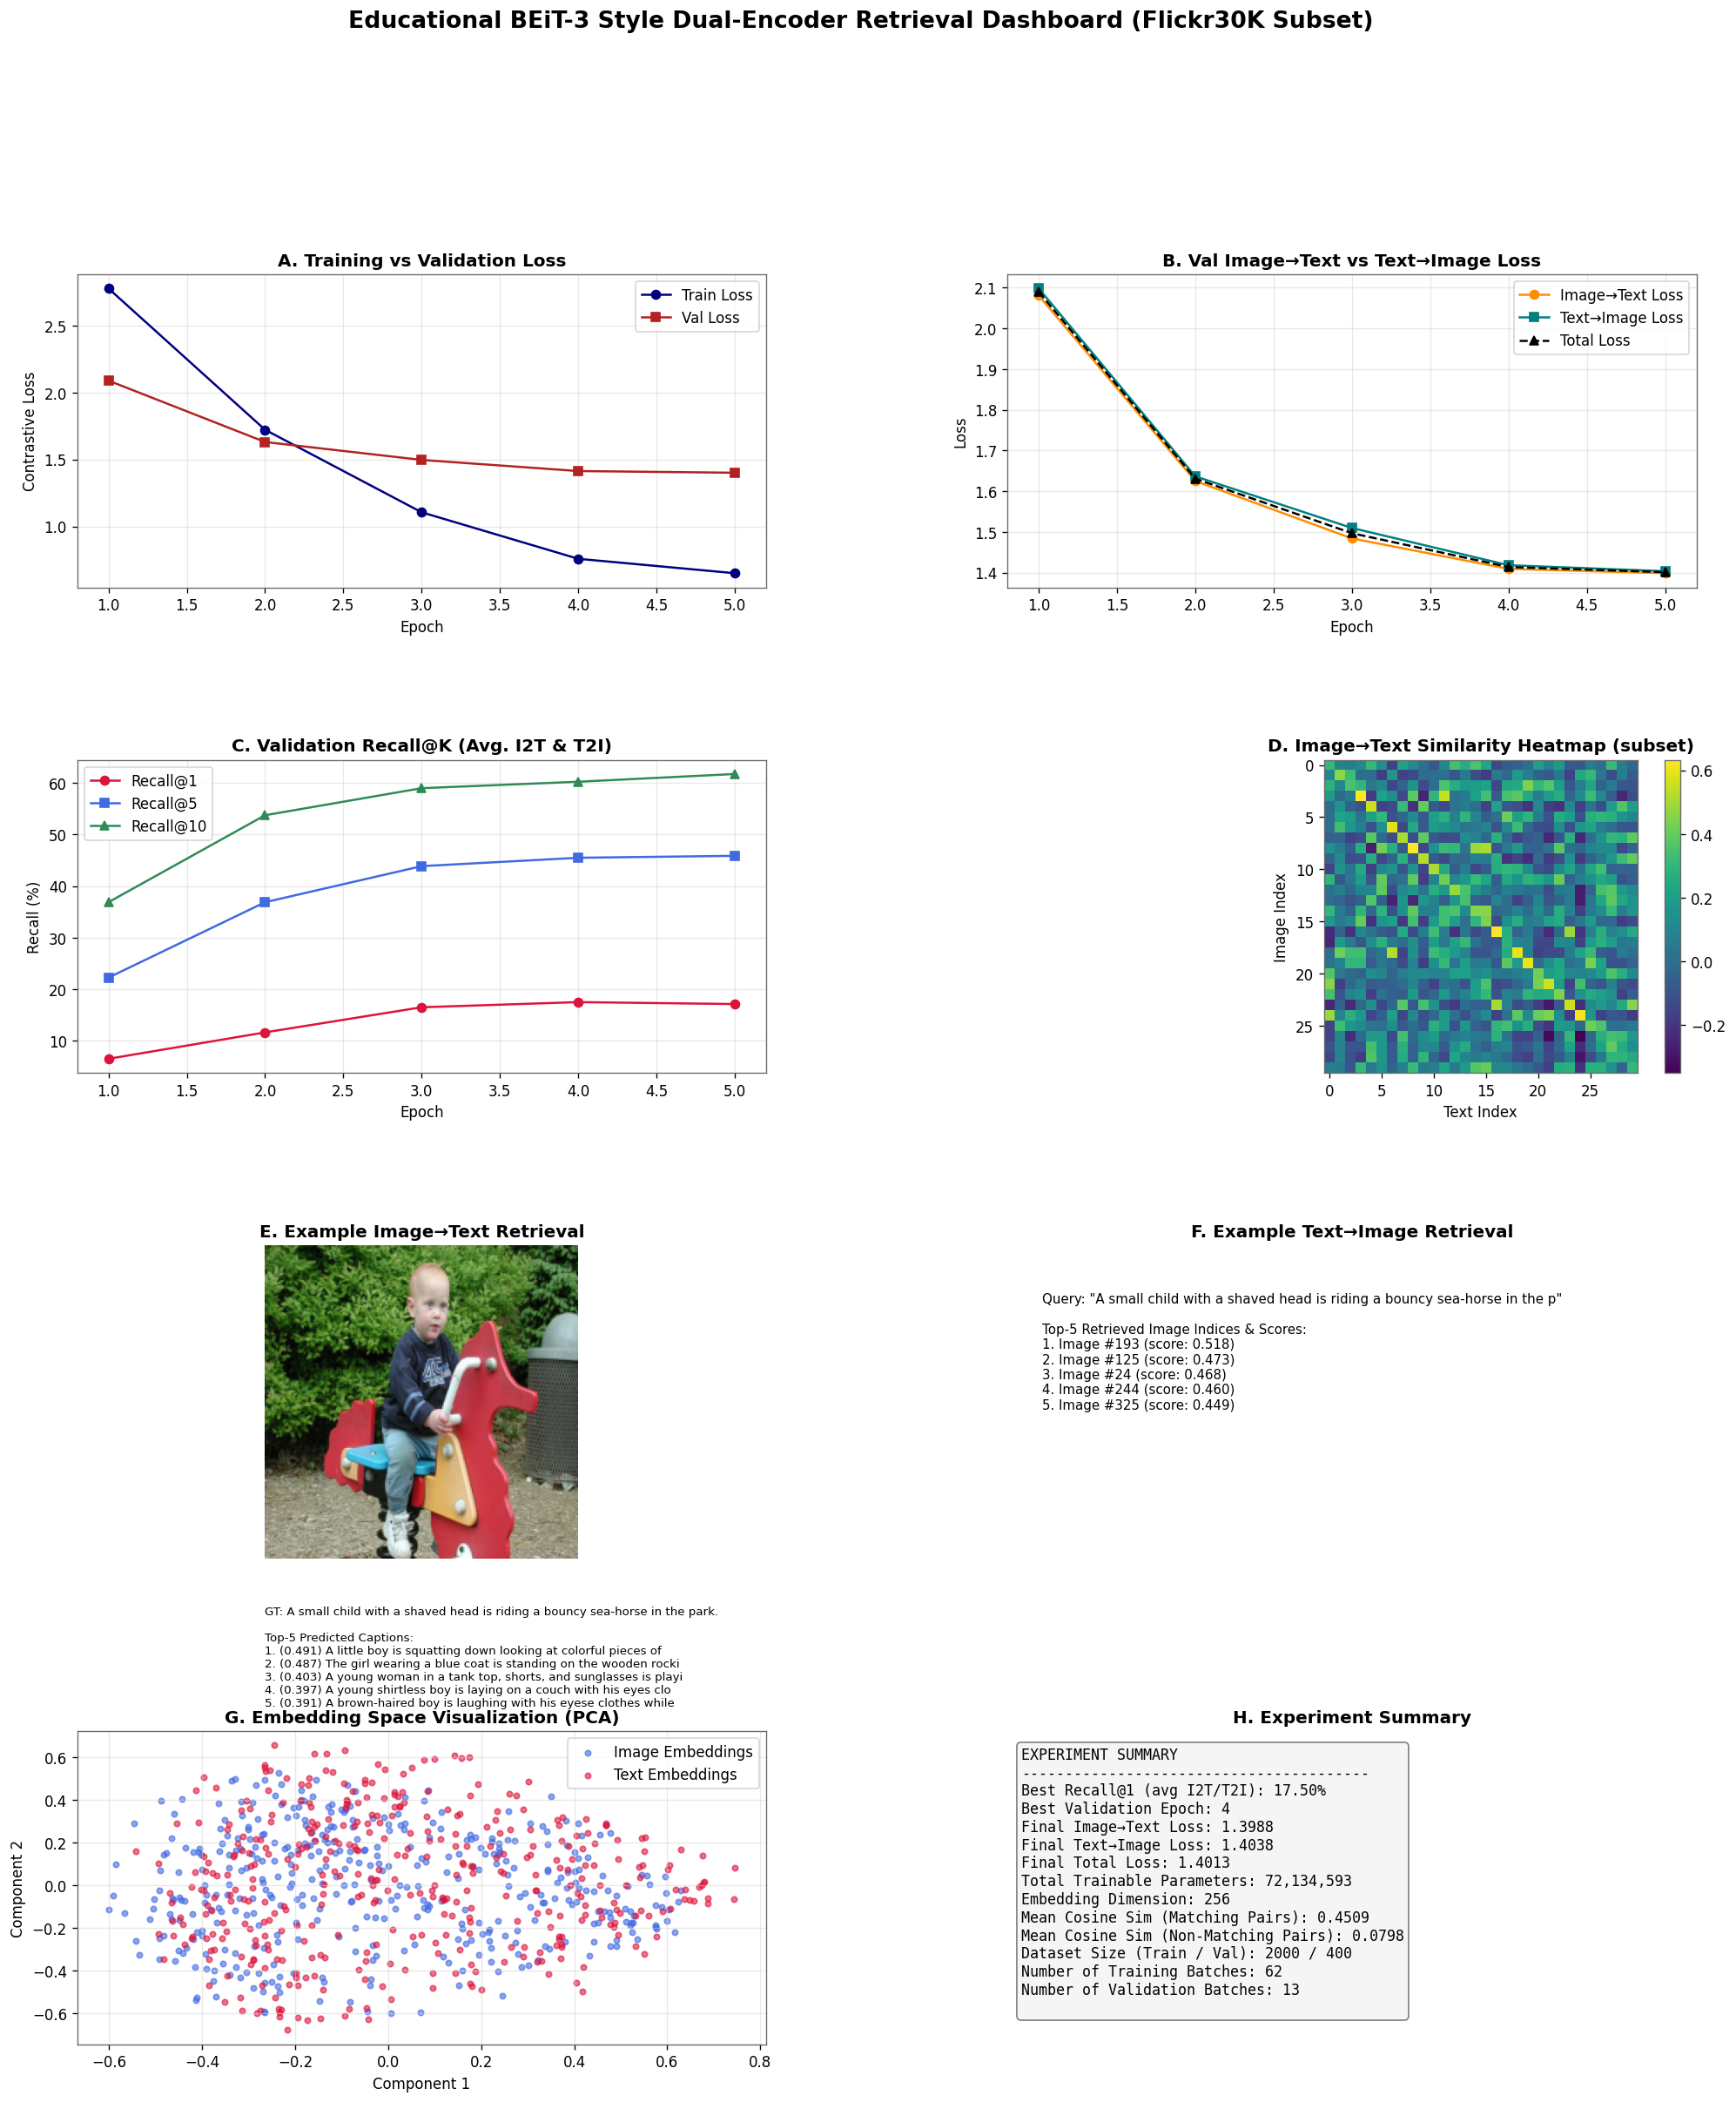

In [19]:

# ============================================================================
# 17. Publication-Style Dashboard
# ============================================================================
epochs_range = list(range(1, NUM_EPOCHS + 1))

fig = plt.figure(figsize=(20, 22), facecolor="white")
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

# ---------------------------- Panel A: Train/Val Loss ----------------------
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(epochs_range, history["train_loss"], marker="o", color="navy", label="Train Loss")
ax_a.plot(epochs_range, history["val_loss"], marker="s", color="firebrick", label="Val Loss")
ax_a.set_title("A. Training vs Validation Loss", fontweight="bold")
ax_a.set_xlabel("Epoch")
ax_a.set_ylabel("Contrastive Loss")
ax_a.legend()
ax_a.grid(True)

# ------------------------- Panel B: I2T / T2I / Total Loss -----------------
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(epochs_range, history["val_i2t_loss"], marker="o", color="darkorange", label="Image→Text Loss")
ax_b.plot(epochs_range, history["val_t2i_loss"], marker="s", color="teal", label="Text→Image Loss")
ax_b.plot(epochs_range, history["val_loss"], marker="^", color="black", linestyle="--", label="Total Loss")
ax_b.set_title("B. Val Image→Text vs Text→Image Loss", fontweight="bold")
ax_b.set_xlabel("Epoch")
ax_b.set_ylabel("Loss")
ax_b.legend()
ax_b.grid(True)

# ------------------------------ Panel C: Recall -----------------------------
ax_c = fig.add_subplot(gs[1, 0])
ax_c.plot(epochs_range, history["val_recall_at_1"], marker="o", color="crimson", label="Recall@1")
ax_c.plot(epochs_range, history["val_recall_at_5"], marker="s", color="royalblue", label="Recall@5")
ax_c.plot(epochs_range, history["val_recall_at_10"], marker="^", color="seagreen", label="Recall@10")
ax_c.set_title("C. Validation Recall@K (Avg. I2T & T2I)", fontweight="bold")
ax_c.set_xlabel("Epoch")
ax_c.set_ylabel("Recall (%)")
ax_c.legend()
ax_c.grid(True)

# ------------------------- Panel D: Similarity Heatmap ----------------------
ax_d = fig.add_subplot(gs[1, 1])
heatmap_size = min(30, final_val_similarity_matrix.size(0))  # keep readable
heatmap_data = final_val_similarity_matrix[:heatmap_size, :heatmap_size].numpy()
im = ax_d.imshow(heatmap_data, cmap="viridis")
ax_d.set_title("D. Image→Text Similarity Heatmap (subset)", fontweight="bold")
ax_d.set_xlabel("Text Index")
ax_d.set_ylabel("Image Index")
fig.colorbar(im, ax=ax_d, fraction=0.046, pad=0.04)

# --------------------- Panel E: Example Image→Text Retrieval ---------------
ax_e = fig.add_subplot(gs[2, 0])
ax_e.axis("off")
example_idx = 0
example_image_sample = val_subset[example_idx]
example_image_tensor = example_image_sample["image_tensor"]
example_gt_caption = example_image_sample["raw_caption"]
top5_captions = retrieve_captions(example_image_tensor, top_k=5)

# Un-normalize the image tensor for display purposes
mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std_t = torch.tensor(IMAGENET_STD).view(3, 1, 1)
display_img = (example_image_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

ax_e.imshow(display_img)
caption_text = f"GT: {example_gt_caption}\n\nTop-5 Predicted Captions:\n"
for rank, (cap, score) in enumerate(top5_captions, start=1):
    caption_text += f"{rank}. ({score:.3f}) {cap[:60]}\n"
ax_e.set_title("E. Example Image→Text Retrieval", fontweight="bold")
ax_e.text(0, -0.15, caption_text, transform=ax_e.transAxes, fontsize=8, va="top", wrap=True)

# --------------------- Panel F: Example Text→Image Retrieval ---------------
ax_f = fig.add_subplot(gs[2, 1])
ax_f.axis("off")
example_text_query = final_val_captions[0]
top5_images = retrieve_images(example_text_query, top_k=5)

result_text = f"Query: \"{example_text_query[:70]}\"\n\nTop-5 Retrieved Image Indices & Scores:\n"
for rank, (img_idx, score) in enumerate(top5_images, start=1):
    result_text += f"{rank}. Image #{img_idx} (score: {score:.3f})\n"
ax_f.set_title("F. Example Text→Image Retrieval", fontweight="bold")
ax_f.text(0.05, 0.85, result_text, transform=ax_f.transAxes, fontsize=9, va="top")

# ------------------------ Panel G: Embedding Visualization ------------------
ax_g = fig.add_subplot(gs[3, 0])
combined_embeds = torch.cat([final_val_image_embeds, final_val_text_embeds], dim=0).numpy()
pca = PCA(n_components=2, random_state=SEED)
reduced = pca.fit_transform(combined_embeds)
n_img = final_val_image_embeds.size(0)

ax_g.scatter(reduced[:n_img, 0], reduced[:n_img, 1], c="royalblue", alpha=0.6, label="Image Embeddings", s=15)
ax_g.scatter(reduced[n_img:, 0], reduced[n_img:, 1], c="crimson", alpha=0.6, label="Text Embeddings", s=15)
ax_g.set_title("G. Embedding Space Visualization (PCA)", fontweight="bold")
ax_g.set_xlabel("Component 1")
ax_g.set_ylabel("Component 2")
ax_g.legend()
ax_g.grid(True)

# --------------------------- Panel H: Experiment Summary --------------------
ax_h = fig.add_subplot(gs[3, 1])
ax_h.axis("off")
summary_text = (
    f"EXPERIMENT SUMMARY\n"
    f"{'-'*40}\n"
    f"Best Recall@1 (avg I2T/T2I): {best_recall_at_1:.2f}%\n"
    f"Best Validation Epoch: {best_epoch}\n"
    f"Final Image→Text Loss: {history['val_i2t_loss'][-1]:.4f}\n"
    f"Final Text→Image Loss: {history['val_t2i_loss'][-1]:.4f}\n"
    f"Final Total Loss: {history['val_loss'][-1]:.4f}\n"
    f"Total Trainable Parameters: {total_params:,}\n"
    f"Embedding Dimension: {EMBED_DIM}\n"
    f"Mean Cosine Sim (Matching Pairs): {mean_sim_matching:.4f}\n"
    f"Mean Cosine Sim (Non-Matching Pairs): {mean_sim_nonmatching:.4f}\n"
    f"Dataset Size (Train / Val): {len(train_subset)} / {len(val_subset)}\n"
    f"Number of Training Batches: {len(train_loader)}\n"
    f"Number of Validation Batches: {len(val_loader)}\n"
)
ax_h.text(0.02, 0.95, summary_text, transform=ax_h.transAxes, fontsize=10,
          va="top", family="monospace",
          bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="gray"))
ax_h.set_title("H. Experiment Summary", fontweight="bold")

fig.suptitle(
    "Educational BEiT-3 Style Dual-Encoder Retrieval Dashboard (Flickr30K Subset)",
    fontsize=16, fontweight="bold", color="black", y=0.995
)

# --------------------------- Render Inline (No Save/Show) -------------------
buf = BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
plt.close(fig)